In [1]:
%matplotlib inline
#Reference from https://pytorch.org/

In [2]:
from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.nn import Tanh, Linear, ReLU, Sequential, Conv2d, MaxPool2d, Sigmoid, BatchNorm2d, Flatten, ConvTranspose2d

plt.ion()   # interactive mode

In [3]:
# Data augmentation and normalization for training
# Just normalization for validation
'''
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
'''
data_transforms = {
    'train': transforms.Compose([
        #transforms.RandomResizedCrop(224),
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        #transforms.Resize(256),
        #transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_transforms = {
    'train': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([224, 224]),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


data_dir = '../AddMoreData061823/Class3/TTV'
l = []
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
l.append(datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']))
#l.append(datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test']))
image_datasetss = torch.utils.data.ConcatDataset(l)
image_datasets = {}
image_datasets['train'] = image_datasetss
image_datasets['test'] = datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])
image_datasets['val'] = datasets.ImageFolder(os.path.join(data_dir, 'val'), data_transforms['test'])
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=5,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'test', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test', 'val']}
class_names = image_datasets['test'].classes
print(class_names)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(len( image_datasets['train']))
print(len( image_datasets['val']))
print(len( image_datasets['test']))

['0', '1', '2']
3016
93
98


Visualize a few images
^^^^^^^^^^^^^^^^^^^^^^
Let's visualize a few training images so as to understand the data
augmentations.



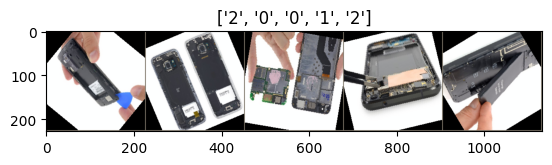

In [4]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs+1):
        print('Epoch {}/{}'.format(epoch+1, num_epochs))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    #print(outputs.shape)
                    #print(outputs)
                    #print(labels)
                    loss = criterion(outputs, labels)
    
                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

Visualizing the model predictions
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Generic function to display predictions for a few images




In [6]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            m = nn.Softmax(dim=1)
            proOutput = m(outputs)
            pros = proOutput.detach().cpu().numpy()
            #print(pros)
            #_, preds = torch.max(outputs, 1)
            #pro = torch.max(proOutput, dim=1)[0]
            #_, predsmin = torch.min(outputs, 1)
            #promin = torch.min(proOutput, dim=1)[0]

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                #ax.set_title('predicted: %s with %s probabilities' %(class_names[preds[j]], round(pro[j].item(),4)))
                print('Actual label: %s' %(class_names[labels[j].item()]))
                for jj in range(3):
                    print('predicted: %s with %s probabilities' %(class_names[jj], round(pros[j][jj],4)))
                #print('predicted: %s with %s probabilities' %(class_names[1], round(pros[j][1],4)))
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
                
        model.train(mode=was_training)

#visualize_model(model_ft)

In [7]:
model_ft = models.resnet50(pretrained=True) #load googlenet.

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

class Res50_rm1stlayer(nn.Module):
    def __init__(self):
        super(Res50_rm1stlayer, self).__init__()
        self.conv1 = model_ft.conv1
        self.bn1 = model_ft.bn1
        self.relu = model_ft.relu
        #self.maxpool = model_ft.maxpool
        self.layer2 = model_ft.layer2
        self.layer3 = model_ft.layer3
        self.layer4 = model_ft.layer4
        self.avgpool = model_ft.avgpool
        self.fc = nn.Linear(2048 ,3)
        
        
    def forward(self, x):
        # Pass data through conv1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        #x = self.maxpool(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)

        return x


Res = Res50_rm1stlayer()
#Res.layer2[0].conv1 = Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
Res.conv1 = Conv2d(3, 256, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Res.bn1 = BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
#Res = Res50_2layers()
#Res = Res50_3layers()
Res = Res.to(device)
print(Res)

C:\Users\haoyuliao\Anaconda3\envs\pytorch3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\haoyuliao\Anaconda3\envs\pytorch3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Res50_rm1stlayer(
  (conv1): Conv2d(3, 256, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer2): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.

Train and evaluate
^^^^^^^^^^^^^^^^^^

It should take around 15-25 min on CPU. On GPU though, it takes less than a
minute.




In [8]:
ep = 100
model_ft = train_model(Res, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=ep)

Epoch 1/100
----------
train Loss: 0.8180 Acc: 0.6648
val Loss: 0.6715 Acc: 0.7742

Epoch 2/100
----------
train Loss: 0.6368 Acc: 0.7530
val Loss: 0.6028 Acc: 0.7634

Epoch 3/100
----------
train Loss: 0.5701 Acc: 0.7732
val Loss: 0.5174 Acc: 0.7634

Epoch 4/100
----------
train Loss: 0.5226 Acc: 0.8034
val Loss: 0.6392 Acc: 0.7419

Epoch 5/100
----------
train Loss: 0.4840 Acc: 0.8150
val Loss: 0.5844 Acc: 0.7312

Epoch 6/100
----------
train Loss: 0.4355 Acc: 0.8302
val Loss: 0.6979 Acc: 0.7742

Epoch 7/100
----------
train Loss: 0.3941 Acc: 0.8534
val Loss: 0.4854 Acc: 0.8387

Epoch 8/100
----------
train Loss: 0.3107 Acc: 0.8932
val Loss: 0.5597 Acc: 0.7957

Epoch 9/100
----------
train Loss: 0.2733 Acc: 0.9052
val Loss: 0.5317 Acc: 0.8172

Epoch 10/100
----------
train Loss: 0.2674 Acc: 0.9125
val Loss: 0.4969 Acc: 0.8387

Epoch 11/100
----------
train Loss: 0.2593 Acc: 0.9105
val Loss: 0.5108 Acc: 0.8172

Epoch 12/100
----------
train Loss: 0.2423 Acc: 0.9227
val Loss: 0.4609 Ac

val Loss: 0.4542 Acc: 0.8495

Epoch 98/100
----------
train Loss: 0.2088 Acc: 0.9387
val Loss: 0.4610 Acc: 0.8495

Epoch 99/100
----------
train Loss: 0.1977 Acc: 0.9456
val Loss: 0.5058 Acc: 0.8387

Epoch 100/100
----------
train Loss: 0.1944 Acc: 0.9469
val Loss: 0.5142 Acc: 0.8065

Epoch 101/100
----------
train Loss: 0.1919 Acc: 0.9469
val Loss: 0.4816 Acc: 0.8387

Training complete in 129m 27s
Best val Acc: 0.870968


Actual label: 1
predicted: 0 with 0.0456 probabilities
predicted: 1 with 0.9059 probabilities
predicted: 2 with 0.0485 probabilities


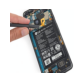

Actual label: 1
predicted: 0 with 0.0131 probabilities
predicted: 1 with 0.9751 probabilities
predicted: 2 with 0.0118 probabilities


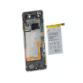

Actual label: 1
predicted: 0 with 0.0244 probabilities
predicted: 1 with 0.9135 probabilities
predicted: 2 with 0.0622 probabilities


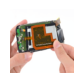

Actual label: 1
predicted: 0 with 0.008 probabilities
predicted: 1 with 0.989 probabilities
predicted: 2 with 0.003 probabilities


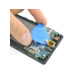

Actual label: 1
predicted: 0 with 0.0152 probabilities
predicted: 1 with 0.9494 probabilities
predicted: 2 with 0.0354 probabilities


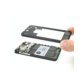

Actual label: 1
predicted: 0 with 0.0021 probabilities
predicted: 1 with 0.9922 probabilities
predicted: 2 with 0.0057 probabilities


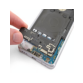

Actual label: 1
predicted: 0 with 0.4176 probabilities
predicted: 1 with 0.5632 probabilities
predicted: 2 with 0.0192 probabilities


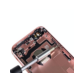

Actual label: 2
predicted: 0 with 0.0088 probabilities
predicted: 1 with 0.8636 probabilities
predicted: 2 with 0.1276 probabilities


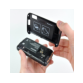

Actual label: 1
predicted: 0 with 0.241 probabilities
predicted: 1 with 0.6318 probabilities
predicted: 2 with 0.1272 probabilities


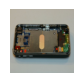

Actual label: 1
predicted: 0 with 0.345 probabilities
predicted: 1 with 0.6379 probabilities
predicted: 2 with 0.0171 probabilities


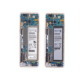

In [9]:
visualize_model(model_ft, 10)

In [10]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['train']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s train images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 3016 train images: 98 %
tensor([[ 386.,   14.,    0.],
        [   8., 2170.,    6.],
        [   0.,   15.,  417.]])
tensor([[0.9650, 0.0350, 0.0000],
        [0.0037, 0.9936, 0.0027],
        [0.0000, 0.0347, 0.9653]])


In [11]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['val']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s val images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 93 val images: 87 %
tensor([[ 9.,  3.,  0.],
        [ 1., 62.,  5.],
        [ 0.,  3., 10.]])
tensor([[0.7500, 0.2500, 0.0000],
        [0.0147, 0.9118, 0.0735],
        [0.0000, 0.2308, 0.7692]])


In [12]:
correct = 0
total = 0
nb_classes = 3
confusion_matrix = torch.zeros(nb_classes, nb_classes)
with torch.no_grad():
    for data in dataloaders['test']:
        images, labels = data[0].cuda(), data[1].cuda()
        outputs = model_ft(images)
        predicted = torch.round(outputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for t, p in zip(labels.view(-1), predicted.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1
        

print('Accuracy of the network on the %s test images: %d %%' % (total,
    100 * correct / total))

print(confusion_matrix)
b= torch.sum(confusion_matrix, dim=1)
print(confusion_matrix/torch.reshape(b, (-1, 1))) #Normalizing


Accuracy of the network on the 98 test images: 85 %
tensor([[ 8.,  6.,  0.],
        [ 3., 64.,  2.],
        [ 0.,  3., 12.]])
tensor([[0.5714, 0.4286, 0.0000],
        [0.0435, 0.9275, 0.0290],
        [0.0000, 0.2000, 0.8000]])


In [13]:
if not os.path.exists('trained models'):
   os.makedirs('trained models')
PATH = './trained models/Res50_rm1st-TTVClass3-BestEP%s.pth' %(ep)
torch.save(model_ft.state_dict(), PATH)